<center>

# [Компьютерное зрение](http://rairi.ru/wiki/index.php/%D0%9A%D0%BE%D0%BC%D0%BF%D1%8C%D1%8E%D1%82%D0%B5%D1%80%D0%BD%D0%BE%D0%B5_%D0%B7%D1%80%D0%B5%D0%BD%D0%B8%D0%B5)

## <center> Семинар 11 - Трекинг

<a target="_blank" href="https://colab.research.google.com/github/alexmelekhin/cv_course_2023/blob/main/seminars/seminar_11/Seminar_11.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

***

In [10]:
# !pip install torch==1.13.1+cu116 torchvision==0.14.1+cu116 --extra-index-url https://download.pytorch.org/whl/cu116
# !pip install ultralytics filterpy lap
# !pip uninstall -y numpy protobuf
# !pip install -U numpy==1.23.5 protobuf==3.20.3

In [15]:
from typing import Tuple
from time import time
import types
from pathlib import Path

from scipy.optimize import linear_sum_assignment
import numpy as np
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

# Вспомогательные функции

In [16]:
def show_image(img: np.ndarray) -> None:
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.show()


def detection_visualization(
    img_path: Path, preds: np.ndarray
) -> np.ndarray:
    img = cv2.imread(str(img_path)) # Read image with cv2
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    for i in range(len(preds)):
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=3,
        )
    return img


def tracking_visualization(
    img_path: Path, preds: np.ndarray
) -> np.ndarray:
    img = cv2.imread(str(img_path)) # Read image with cv2
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    for i in range(len(preds)):
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=3,
        )
        cv2.putText(
            img,
            str(int(preds[i][4])),
            (int(preds[i][0]), int(preds[i][1])),
            cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=2,
            color=(0, 255, 0),
            thickness=3
        )
    return img


In [23]:
dataset_dir = Path("MOT_17_09_imgs")  # путь к директории с изображениями трека MOT17-09
frames_list = sorted([f for f in dataset_dir.iterdir()])

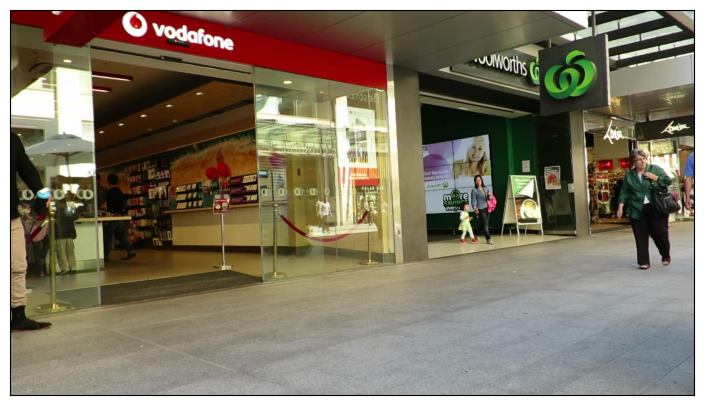

In [24]:
img = cv2.cvtColor(cv2.imread(str(frames_list[0])), cv2.COLOR_BGR2RGB)
show_image(img)

# Детекция с помощью YOLOv8

В качестве бэкбона детекции мы будем использовать YOLOv8s из библиотеки ultralytics: https://github.com/ultralytics/ultralytics

In [25]:
class YoloDetector:
    def __init__(self, conf_threshold: float = 0.5) -> None:
        self.backbone = YOLO("yolov8s.pt")
        self.conf_threshold = conf_threshold
    
    def __call__(self, img_path: Path) -> np.ndarray:
        preds = self.backbone.predict(source=img_path, conf=self.conf_threshold, show=False, classes=0)
        preds = preds[0].boxes.data.cpu().numpy()[:, :5]
        return preds


image 1/1 /home/raibotics/MIPT/cv_course_2026/seminars/seminar_11/MOT_17_09_imgs/000001.jpg: 384x640 7 persons, 36.8ms
Speed: 4.9ms preprocess, 36.8ms inference, 46.2ms postprocess per image at shape (1, 3, 384, 640)


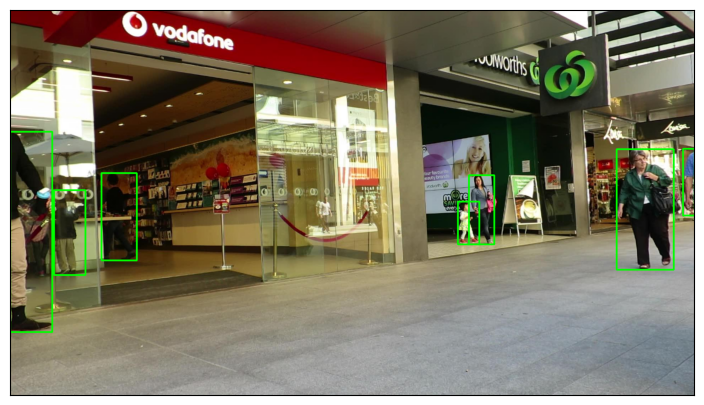

In [26]:
detector = YoloDetector()
preds = detector(frames_list[0])

out_frame = detection_visualization(frames_list[0], preds)
show_image(out_frame)

# Алгоритм трекинга SORT

SORT: https://arxiv.org/abs/1602.00763

Разделы "3.3. Data Association" и "3.4. Creation and Deletion of Track Identities" описывают алгоритм соотнесения результатов детекции последовательных кадров:

> **3.3. Data Association**
> 
> In assigning detections to existing targets, each target’s
> bounding box geometry is estimated by predicting its new
> location in the current frame. The assignment cost matrix is
> then computed as the intersection-over-union (IOU) distance
> between each detection and all predicted bounding boxes
> from the existing targets. The assignment is solved optimally
> using the Hungarian algorithm. Additionally, a minimum
> IOU is imposed to reject assignments where the detection to
> target overlap is less than $IOU_{min}$.
>
> We found that the IOU distance of the bounding boxes
> implicitly handles short term occlusion caused by passing targets.
> Specifically, when a target is covered by an occluding
> object, only the occluder is detected, since the IOU distance
> appropriately favours detections with similar scale. This allows
> both the occluder target to be corrected with the detection while 
> the covered target is unaffected as no assignment is made.

> **3.4. Creation and Deletion of Track Identities**
>
> When objects enter and leave the image, unique identities
> need to be created or destroyed accordingly. For creating
> trackers, we consider any detection with an overlap less than
> $IOU_{min}$ to signify the existence of an untracked object. The
> tracker is initialised using the geometry of the bounding box
> with the velocity set to zero. Since the velocity is unobserved
> at this point the covariance of the velocity component is initialised
> with large values, reflecting this uncertainty. Additionally, the new
> tracker then undergoes a probationary period where the target needs
> to be associated with detections to accumulate enough evidence in order
> to prevent tracking of false positives.
> 
> Tracks are terminated if they are not detected for $T_{Lost}$
> frames. This prevents an unbounded growth in the number
> of trackers and localisation errors caused by predictions over
> long durations without corrections from the detector. In all
> experiments $T_{Lost}$ is set to 1 for two reasons. Firstly, the constant
> velocity model is a poor predictor of the true dynamics
> and secondly we are primarily concerned with frame-to-frame
> tracking where object re-identification is beyond the scope of
> this work. Additionally, early deletion of lost targets aids efficiency.
> Should an object reappear, tracking will implicitly resume under a new identity.

# Венгерский алгоритм (Hungarian algorithm)

- [Wikipedia](https://en.wikipedia.org/wiki/Hungarian_algorithm)
- Реализация в библиотеке scipy: [`scipy.optimize.linear_sum_assignment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html)
- Реализация в библиотеке [lap](https://github.com/gatagat/lap): `lap.lapjv` 

## Задание 1:

Реализуйте Венгерский алгоритм. Сравните возвращаемые значения с библиотечной функцией [`scipy.optimize.linear_sum_assignment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html).

In [27]:
from typing import Tuple
import numpy as np

def hungarian_algorithm(cost_matrix: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Решает задачу о назначениях (минимальная стоимость) венгерским алгоритмом.

    Параметры
    ----------
    cost_matrix : np.ndarray
        Матрица стоимостей размера (n, m), где n – число работников, m – число задач.
        Допускается n != m, алгоритм добавляет фиктивные нулевые строки/столбцы.

    Возвращает
    ----------
    Tuple[np.ndarray, np.ndarray]
        row_ind, col_ind – индексы выбранных ячеек, соответствие взаимно однозначное,
        количество пар равно min(n, m). Сортированы по возрастанию row_ind.
    """
    cost = np.asarray(cost_matrix, dtype=float)
    if cost.ndim != 2:
        raise ValueError("cost_matrix must be a 2D array")

    n_rows, n_cols = cost.shape
    if n_rows == 0 or n_cols == 0:
        return np.array([], dtype=int), np.array([], dtype=int)

    # Приводим к случаю n_rows <= n_cols транспонированием
    transposed = n_rows > n_cols
    if transposed:
        cost = cost.T
        n_rows, n_cols = cost.shape

    # Потенциалы и вспомогательные массивы
    u = np.zeros(n_rows + 1)          # потенциалы строк
    v = np.zeros(n_cols + 1)          # потенциалы столбцов
    p = np.zeros(n_cols + 1, dtype=int)  # пары: p[j] = i (строка, назначенная столбцу j)
    way = np.zeros(n_cols + 1, dtype=int)

    # Основной цикл: добавляем по одной строке
    for i in range(1, n_rows + 1):
        p[0] = i          # фиктивный столбец
        j0 = 0
        minv = np.full(n_cols + 1, np.inf)
        used = np.zeros(n_cols + 1, dtype=bool)

        while True:
            used[j0] = True
            i0 = p[j0]    # текущая строка, рассматриваемая для переброски
            delta = np.inf
            j1 = 0

            # Ищем наименьшее значение с учётом потенциалов
            for j in range(1, n_cols + 1):
                if used[j]:
                    continue
                cur = cost[i0 - 1, j - 1] - u[i0] - v[j]
                if cur < minv[j]:
                    minv[j] = cur
                    way[j] = j0
                if minv[j] < delta:
                    delta = minv[j]
                    j1 = j

            # Обновляем потенциалы
            for j in range(n_cols + 1):
                if used[j]:
                    u[p[j]] += delta
                    v[j] -= delta
                else:
                    minv[j] -= delta

            j0 = j1
            if p[j0] == 0:
                break

        # Восстанавливаем цепочку назначений
        while True:
            j1 = way[j0]
            p[j0] = p[j1]
            j0 = j1
            if j0 == 0:
                break

    # Формируем результат: только реальные строки (p[j] != 0)
    row_ind = []
    col_ind = []
    for j in range(1, n_cols + 1):
        if p[j] != 0:
            row_ind.append(p[j] - 1)   # нумерация с 0
            col_ind.append(j - 1)

    row_ind = np.asarray(row_ind, dtype=int)
    col_ind = np.asarray(col_ind, dtype=int)

    # Обратная транспонировка, если было
    if transposed:
        row_ind, col_ind = col_ind, row_ind

    # Возвращаем в порядке возрастания строк
    order = np.argsort(row_ind)
    return row_ind[order], col_ind[order]

In [28]:
cost_matrix = np.array([[1, 2, 3],
                        [4, 5, 6],
                        [7, 8, 9]])
my_row_ind, my_col_ind = hungarian_algorithm(cost_matrix)
my_cost = cost_matrix[my_row_ind, my_col_ind].sum()
row_ind, col_ind = linear_sum_assignment(cost_matrix)
cost = cost_matrix[row_ind, col_ind].sum()

assert my_cost == cost

# Алгоритм трекинга ByteTrack

- Статья https://arxiv.org/abs/2110.06864
- Код https://github.com/ifzhang/ByteTrack


## Вопрос 1:

В чем заключается ключевая особенность метода BYTE?

**Ответ:** ключевая идея BYTE заключается в том, что алгоритм не отбрасывает все низкоуверенные детекции сразу. Сначала он сопоставляет треки с высокоуверенными детекциями, а затем использует оставшиеся низкоуверенные детекции для повторного сопоставления потерянных треков. Это помогает сохранять ID при частичных перекрытиях и временном падении confidence у детектора, при этом фоновые ложные срабатывания не закрепляются за треками обычно.

In [33]:
!git clone https://github.com/ifzhang/ByteTrack.git
%cd ByteTrack
!pip install -r requirements.txt
!python setup.py develop
%cd ..
!pip install cython
!pip install 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'
!pip install cython_bbox

Cloning into 'ByteTrack'...
remote: Enumerating objects: 2007, done.
remote: Counting objects: 100% (325/325), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 2007 (delta 292), reused 284 (delta 284), pack-reused 1682 (from 1)
Receiving objects: 100% (2007/2007), 79.60 MiB | 3.27 MiB/s, done.
Resolving deltas: 100% (1159/1159), done.
/home/raibotics/MIPT/cv_course_2026/seminars/seminar_11/ByteTrack
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 7.5 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Could not find a version that satisfies the requirement onnxruntime==1.8.0 (from versions: 1.17.0, 1.17.1, 1.17.3, 1.18.0, 1.18.1, 1.19.0, 1.19.2, 1.20.0, 1.20.1, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.23.0, 1.23.1, 1.23.2, 1.24.0

In [40]:
!pip install --upgrade setuptools build wheel
!pip install lap
!pip install bytetracker


  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
Using cached wheel-0.47.0-py3-none-any.whl (32 kB)
  Using cached bytetracker-0.3.2.tar.gz (11 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached lap-0.4.0.tar.gz (1.5 MB)
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [6 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 34, in <module>
        File "/tmp/pip-install-eau7qb00/lap_84dd670c67374827a26c1a11db615b39/setup.py", line 4, in <module>
          from pkg_resources import parse_version
      ModuleNotFoundError: No module named 'pkg_resources'
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error

In [41]:
import numpy as np
from scipy.optimize import linear_sum_assignment
from collections import deque

def iou_batch(boxes1, boxes2):
    """Векторизованный IoU между двумя наборами боксов [x1,y1,x2,y2]."""
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    lt = np.maximum(boxes1[:, None, :2], boxes2[:, :2])   # левый верх
    rb = np.minimum(boxes1[:, None, 2:], boxes2[:, 2:])   # правый низ
    wh = np.maximum(0.0, rb - lt)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2 - inter
    return inter / (union + 1e-6)


class SimpleByteTrack:
    def __init__(self, track_thresh=0.5, match_thresh=0.8, track_buffer=30, frame_rate=30):
        """
        Параметры:
            track_thresh: порог уверенности, выше которого детекция считается высокой (high)
            match_thresh: IoU порог для первого матчинга (высокие детекции)
            track_buffer: сколько кадров трек может оставаться потерянным
            frame_rate: для совместимости с интерфейсом (не используется)
        """
        self.track_thresh = track_thresh
        self.match_thresh = match_thresh
        self.track_buffer = track_buffer
        self.frame_rate = frame_rate

        self.next_id = 0
        self.active_tracks = []   # список словарей треков
        self.lost_tracks = []

    def update(self, detections):
        """
        Принимает detections [N, 5]: [x1, y1, x2, y2, score].
        Возвращает массив активных треков [M, 5]: [x1, y1, x2, y2, track_id].
        """
        if len(detections) == 0:
            # Обновляем счётчики потерянных треков
            self._handle_lost_tracks([])
            return self._active_tracks_array()

        # Разделяем на высоко- (>= порог) и низко-уверенные
        high_mask = detections[:, 4] >= self.track_thresh
        dets_high = detections[high_mask]
        dets_low = detections[~high_mask]

        # Все существующие треки (активные + потерянные)
        all_tracks = self.active_tracks + self.lost_tracks
        track_boxes = np.array([t['box'] for t in all_tracks]) if all_tracks else np.empty((0, 4))

        # ----- Первый матчинг: высокие детекции со всеми треками -----
        matched, unmatched_high, unmatched_tracks = self._match_detections_to_tracks(
            dets_high, all_tracks, self.match_thresh)

        # Обновление совпавших треков
        for i_track, i_det in matched:
            track = all_tracks[i_track]
            track['box'] = dets_high[i_det][:4]
            track['score'] = dets_high[i_det][4]
            track['time_since_update'] = 0
            # Вернуть из потерянных, если был там
            if track in self.lost_tracks:
                self.lost_tracks.remove(track)
                self.active_tracks.append(track)

        # ----- Второй матчинг: оставшиеся низкие детекции с оставшимися треками -----
        remaining_tracks = [all_tracks[i] for i in unmatched_tracks]
        if len(dets_low) > 0 and len(remaining_tracks) > 0:
            # Используем более мягкий порог (по умолчанию 0.5)
            matched_low, _, _ = self._match_detections_to_tracks(
                dets_low, remaining_tracks, 0.5)
            for i_track, i_det in matched_low:
                track = remaining_tracks[i_track]
                track['box'] = dets_low[i_det][:4]
                track['score'] = dets_low[i_det][4]
                track['time_since_update'] = 0

        # ----- Создание новых треков из несовпавших высоких детекций -----
        for idx in unmatched_high:
            det = dets_high[idx]
            new_track = {
                'id': self.next_id,
                'box': det[:4].copy(),
                'score': det[4],
                'time_since_update': 0,
                'history': deque(maxlen=self.track_buffer)
            }
            self.next_id += 1
            self.active_tracks.append(new_track)

        # ----- Обработка потерянных треков (увеличение счётчика) -----
        self._handle_lost_tracks(unmatched_tracks, all_tracks)

        # Возврат активных треков
        return self._active_tracks_array()

    def _match_detections_to_tracks(self, detections, tracks, iou_threshold):
        """Венгерский алгоритм на основе IoU.
        Возвращает: (matched_pairs, unmatched_det_idx, unmatched_track_idx)"""
        if len(tracks) == 0 or len(detections) == 0:
            return [], list(range(len(detections))), list(range(len(tracks)))

        track_boxes = np.array([t['box'] for t in tracks])
        det_boxes = detections[:, :4]

        iou_matrix = iou_batch(det_boxes, track_boxes)  # [N_det, N_track]

        # Венгерский алгоритм (минимизация -iou)
        row_ind, col_ind = linear_sum_assignment(-iou_matrix)

        matched = []
        unmatched_det = set(range(len(detections)))
        unmatched_track = set(range(len(tracks)))

        for r, c in zip(row_ind, col_ind):
            if iou_matrix[r, c] >= iou_threshold:
                matched.append((c, r))  # (track_idx, det_idx)
                unmatched_det.discard(r)
                unmatched_track.discard(c)

        return matched, list(unmatched_det), list(unmatched_track)

    def _handle_lost_tracks(self, unmatched_track_indices, all_tracks=None):
        """Увеличивает счётчик времени для треков, которые не обновились."""
        # Если не переданы все треки, берём активные + потерянные
        if all_tracks is None:
            all_tracks = self.active_tracks + self.lost_tracks
        # Отмечаем неудачные треки
        for i in unmatched_track_indices:
            track = all_tracks[i]
            track['time_since_update'] += 1

        # Перемещаем треки с истекшим буфером в удалённые, иначе в потерянные
        for track in all_tracks:
            if track['time_since_update'] > self.track_buffer:
                if track in self.active_tracks:
                    self.active_tracks.remove(track)
                if track in self.lost_tracks:
                    self.lost_tracks.remove(track)
            elif track['time_since_update'] > 0:
                # Если ещё жив, но не обновлён – переносим в lost
                if track in self.active_tracks:
                    self.active_tracks.remove(track)
                    if track not in self.lost_tracks:
                        self.lost_tracks.append(track)

    def _active_tracks_array(self):
        """Возвращает массив активных треков [x1, y1, x2, y2, id]."""
        if not self.active_tracks:
            return np.empty((0, 5))
        arr = np.array([np.append(t['box'], t['id']) for t in self.active_tracks])
        return arr

In [43]:
import numpy as np
import cv2
import time
from pathlib import Path

# -----------------------------------------------
# 2. Параметры трекера
# -----------------------------------------------
tracker = SimpleByteTrack(
    track_thresh=0.5,      # порог «высокой» уверенности
    match_thresh=0.8,      # IoU для первого матчинга
    track_buffer=30,       # сколько кадров держать потерянный трек
    frame_rate=30          # не используется, оставлено для совместимости
)

# -----------------------------------------------
# 3. Настройка видео
# -----------------------------------------------
fps = 30
frame_size = (1080, 1920)   # (высота, ширина) – у вас так?
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_file = 'output.mp4'

# Обратите внимание: VideoWriter ожидает (ширина, высота), поэтому frame_size[::-1]
video_writer = cv2.VideoWriter(output_file, fourcc, fps, (frame_size[1], frame_size[0]))

det_times = []
track_times = []

# -----------------------------------------------
# 4. Цикл по кадрам
# -----------------------------------------------
for frame_path in frames_list:
    # --- Детекция ---
    t_start = time.time()
    detections = detector(frame_path)   # должен вернуть np.array [N,5]: x1,y1,x2,y2,score
    det_times.append((time.time() - t_start) * 1000)  # мс

    # --- Трекинг ---
    t_start = time.time()
    # ВАЖНОЕ отличие: наш tracker.update принимает только detections,
    # ему не нужны frame_size и img_info
    tracks = tracker.update(detections)
    track_times.append((time.time() - t_start) * 1000)

    # tracks уже в формате [x1, y1, x2, y2, track_id] – готов к визуализации
    # Убедитесь, что tracking_visualization ожидает именно такой список
    out_frame = tracking_visualization(frame_path, tracks)

    # Запись в видео
    video_writer.write(cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))

video_writer.release()

print(f"Среднее время детекции: {np.mean(det_times):.2f} мс, "
      f"среднее время трекинга: {np.mean(track_times):.2f} мс")


image 1/1 /home/raibotics/MIPT/cv_course_2026/seminars/seminar_11/MOT_17_09_imgs/000001.jpg: 384x640 7 persons, 13.0ms
Speed: 12.1ms preprocess, 13.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/raibotics/MIPT/cv_course_2026/seminars/seminar_11/MOT_17_09_imgs/000002.jpg: 384x640 7 persons, 3.9ms
Speed: 1.4ms preprocess, 3.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/raibotics/MIPT/cv_course_2026/seminars/seminar_11/MOT_17_09_imgs/000003.jpg: 384x640 7 persons, 3.5ms
Speed: 1.4ms preprocess, 3.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/raibotics/MIPT/cv_course_2026/seminars/seminar_11/MOT_17_09_imgs/000004.jpg: 384x640 7 persons, 3.4ms
Speed: 1.4ms preprocess, 3.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/raibotics/MIPT/cv_course_2026/seminars/seminar_11/MOT_17_09_imgs/000005.jpg: 384x640 7 persons, 3.4ms
Speed: 1.2ms prepr

## Задание 2

Объедините BYTE и любой трекер с Re-ID признаками (например, FairMOT). Можно воспользоваться инструкциями из репозитория: https://github.com/ifzhang/ByteTrack/tree/main/tutorials

Ответом на это задание должен быть код, записывающий видео работы метода для трека MOT17-09 в файл `reid_out.mp4`. Убедитесь, что код работает "end-to-end". 

In [49]:
pip install torchreid gdown tensorboard

  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 7.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 9.1 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.2/108.2 kB 6.7 MB/s eta 0:00:00
Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl (324 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 7.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 7.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO # Для детекций
from torchreid.reid.utils import FeatureExtractor
from scipy.spatial.distance import cdist

VIDEO_PATH = "MOT17" # Путь к кадрам MOT17-09
OUTPUT_VIDEO = "reid_out.mp4"
FRAME_RATE = 30

class ByteReIDTracker(SimpleByteTrack):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Инициализируем экстрактор признаков (Re-ID)
        self.encoder = FeatureExtractor(
            model_name='osnet_x1_0',
            device='cuda' if torch.cuda.is_available() else 'cpu'
        )
        self.lambda_reid = 0.4 # Вес Re-ID в итоговой метрике

    def get_features(self, frame, boxes):
        """Извлекает эмбеддинги для обрезанных объектов."""
        crops = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                crops.append(np.zeros((3, 256, 128))) # Заглушка
            else:
                crops.append(crop)
        
        if not crops: return np.empty((0, 512))
        features = self.encoder(crops)
        return features.cpu().detach().numpy()

    def _match_with_reid(self, detections, tracks, iou_threshold, det_features):
        """Расширенный матчинг: IoU + Re-ID косинусное расстояние."""
        if not tracks or len(detections) == 0:
            return [], list(range(len(detections))), list(range(len(tracks)))

        det_boxes = detections[:, :4]
        track_boxes = np.array([t['box'] for t in tracks])
        track_features = np.array([t['feat'] for t in tracks])

        # Считаем IoU матрицу
        iou_sim = iou_batch(det_boxes, track_boxes)
        
        # Считаем Re-ID сходство (1 - cosine distance)
        reid_sim = 1 - cdist(det_features, track_features, metric='cosine')
        
        # Комбинированная матрица
        combined_sim = (1 - self.lambda_reid) * iou_sim + self.lambda_reid * reid_sim
        
        # Венгерский алгоритм
        from scipy.optimize import linear_sum_assignment
        row_ind, col_ind = linear_sum_assignment(-combined_sim)

        matched, unmatched_det, unmatched_track = [], set(range(len(detections))), set(range(len(tracks)))
        for r, c in zip(row_ind, col_ind):
            if combined_sim[r, c] >= iou_threshold:
                matched.append((c, r))
                unmatched_det.discard(r)
                unmatched_track.discard(c)
        
        return matched, list(unmatched_det), list(unmatched_track)

# --- Основной цикл обработки ---

def run_tracking():
    # Загружаем модель детекции (YOLOv8 обученная на COCO/MOT)
    detector = YOLO('yolov8n.pt') 
    tracker = ByteReIDTracker(track_thresh=0.45, match_thresh=0.7)
    
    # Настройка видео-врайтера
    cap = cv2.VideoCapture("MOT17-09-raw.mp4") # Или путь к картинкам
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(OUTPUT_VIDEO, cv2.VideoWriter_fourcc(*'mp4v'), FRAME_RATE, (width, height))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Детекция (только люди - class 0)
        results = detector(frame, classes=[0], verbose=False)[0]
        dets = results.boxes.data.cpu().numpy() # [x1, y1, x2, y2, conf, cls]
        
        # Извлекаем признаки для всех детекций
        if len(dets) > 0:
            features = tracker.get_features(frame, dets[:, :4])
        else:
            features = np.empty((0, 512))

        # 3. Обновление трекера (модифицированный update с учетом признаков)
        online_targets = tracker.update_with_reid(dets, features)

        # 4. Визуализация
        for t in online_targets:
            x1, y1, x2, y2, obj_id = map(int, t)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"ID: {obj_id}", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        out.write(frame)

    cap.release()
    out.release()
    print(f"Результат сохранен в {OUTPUT_VIDEO}")

if __name__ == "__main__":
    run_tracking()

Downloading...
From: https://drive.google.com/uc?id=1LaG1EJpHrxdAxKnSCJ_i0u-nbxSAeiFY
To: /home/raibotics/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth
100%|██████████| 10.9M/10.9M [00:01<00:00, 9.41MB/s]


Successfully loaded imagenet pretrained weights from "/home/raibotics/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']
Model: osnet_x1_0
- params: 2,193,616
- flops: 978,878,352
Результат сохранен в reid_out.mp4
